## 1. Imports


In [20]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.metrics import confusion_matrix, classification_report

## 2. Load the Dataset

The dataset is loaded using `tensorflow_datasets`.

In [21]:
train_set_raw, validation_set_raw, test_set_raw = tfds.load(
    name="horses_or_humans",
    split=["train[:90%]", "train[90%:]", "test"],
    as_supervised=True
)

class_names = ["horse", "human"]

## 3. Inspect the Data

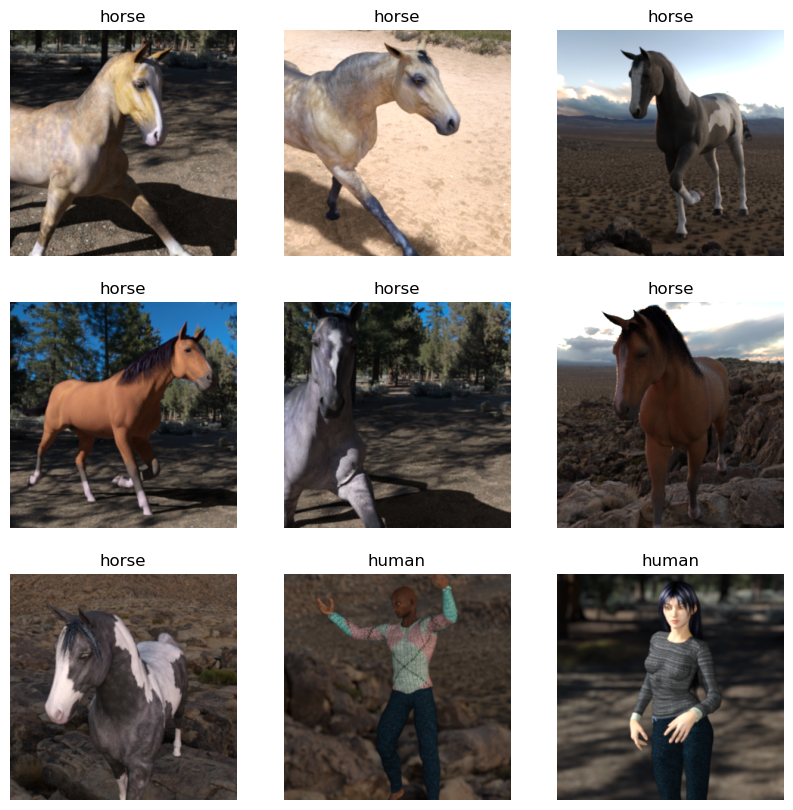

In [22]:
plt.figure(figsize=(10, 10))

for i, (image, label) in enumerate(train_set_raw.take(9)):
    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(class_names[int(label)])
    plt.axis("off")

plt.show()

## 4. Data Preparation

The original images are 300×300 RGB images.

The images are resized to **224×224**, because MobileNetV2 expects this format by default.

In [23]:
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE


def prepare_for_cnn(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label


def prepare_for_mobilenet(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)
    return image, label


train_cnn = (
    train_set_raw
    .shuffle(buffer_size=10_000, seed=42)
    .map(prepare_for_cnn, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

validation_cnn = (
    validation_set_raw
    .map(prepare_for_cnn, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(AUTOTUNE)
)

test_cnn = (
    test_set_raw
    .map(prepare_for_cnn, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(AUTOTUNE)
)


train_transfer = (
    train_set_raw
    .shuffle(buffer_size=10_000, seed=42)
    .map(prepare_for_mobilenet, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

validation_transfer = (
    validation_set_raw
    .map(prepare_for_mobilenet, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(AUTOTUNE)
)

test_transfer = (
    test_set_raw
    .map(prepare_for_mobilenet, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(AUTOTUNE)
)

print("Data preparation completed.")


Data preparation completed.


## 5. Baseline CNN Model


In [24]:
cnn_model = keras.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])

cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Train the Baseline CNN

The CNN is trained for 10 epochs. During training, validation accuracy and validation loss are tracked to detect underfitting or overfitting.

In [25]:
CNN_EPOCHS = 10

cnn_history = cnn_model.fit(
    train_cnn,
    validation_data=validation_cnn,
    epochs=CNN_EPOCHS
)


Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 127ms/step - accuracy: 0.7543 - loss: 0.5424 - val_accuracy: 0.8641 - val_loss: 0.2452
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 124ms/step - accuracy: 0.9654 - loss: 0.1135 - val_accuracy: 0.9806 - val_loss: 0.0762
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - accuracy: 0.9881 - loss: 0.0388 - val_accuracy: 0.9903 - val_loss: 0.0276
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 124ms/step - accuracy: 0.9935 - loss: 0.0228 - val_accuracy: 0.9903 - val_loss: 0.0263
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - accuracy: 0.9827 - loss: 0.0537 - val_accuracy: 1.0000 - val_loss: 0.0177
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 121ms/step - accuracy: 0.9924 - loss: 0.0236 - val_accuracy: 1.0000 - val_loss: 0.0063
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 121ms/step - accuracy: 1.0000 - loss: 0.0056 - val_accuracy: 1.0000 - val_loss: 0.0014
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 121ms/step - accuracy: 0.9935 - loss: 0.0196 - val_accuracy: 1.

## 7. Evaluate the Baseline CNN

The test set is only used after training. This gives a more realistic estimate of how the model performs on unseen data.

In [26]:
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(test_cnn)

print(f"CNN test accuracy: {cnn_test_accuracy:.4f}")
print(f"CNN test loss: {cnn_test_loss:.4f}")


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8516 - loss: 2.2525
CNN test accuracy: 0.8516
CNN test loss: 2.2525


## 8. Transfer Learning with MobileNetV2

The second model uses MobileNetV2 as a pre-trained feature extractor.

In [27]:
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

transfer_model = keras.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

transfer_model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 9. Train the Transfer-Learning Model

In [28]:
TRANSFER_EPOCHS = 5

transfer_history = transfer_model.fit(
    train_transfer,
    validation_data=validation_transfer,
    epochs=TRANSFER_EPOCHS
)


Epoch 1/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - accuracy: 0.8290 - loss: 0.3807 - val_accuracy: 1.0000 - val_loss: 0.0921
Epoch 2/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - accuracy: 0.9946 - loss: 0.0642 - val_accuracy: 1.0000 - val_loss: 0.0355
Epoch 3/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - accuracy: 0.9968 - loss: 0.0333 - val_accuracy: 1.0000 - val_loss: 0.0226
Epoch 4/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.9968 - loss: 0.0223 - val_accuracy: 1.0000 - val_loss: 0.0171
Epoch 5/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - accuracy: 0.9968 - loss: 0.0215 - val_accuracy: 1.0000 - val_loss: 0.0126


## 10. Evaluate the Transfer-Learning Model


In [29]:
transfer_test_loss, transfer_test_accuracy = transfer_model.evaluate(test_transfer)

print(f"Transfer learning test accuracy: {transfer_test_accuracy:.4f}")
print(f"Transfer learning test loss: {transfer_test_loss:.4f}")


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.9961 - loss: 0.0345
Transfer learning test accuracy: 0.9961
Transfer learning test loss: 0.0345


## 11. Fine-Tuning


In [30]:
base_model.trainable = True

# Freeze all layers except the last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.00001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Number of trainable layers in base model:", sum(layer.trainable for layer in base_model.layers))


Number of trainable layers in base model: 30


## 12. Train the Fine-Tuned Model

In [31]:
FINE_TUNE_EPOCHS = 5

fine_tune_history = transfer_model.fit(
    train_transfer,
    validation_data=validation_transfer,
    epochs=FINE_TUNE_EPOCHS
)


Epoch 1/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 135ms/step - accuracy: 0.9913 - loss: 0.0617 - val_accuracy: 1.0000 - val_loss: 0.0054
Epoch 2/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 121ms/step - accuracy: 1.0000 - loss: 0.0284 - val_accuracy: 1.0000 - val_loss: 0.0029
Epoch 3/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 121ms/step - accuracy: 1.0000 - loss: 0.0139 - val_accuracy: 1.0000 - val_loss: 0.0019
Epoch 4/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - accuracy: 0.9989 - loss: 0.0101 - val_accuracy: 1.0000 - val_loss: 0.0014
Epoch 5/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 121ms/step - accuracy: 1.0000 - loss: 0.0067 - val_accuracy: 1.0000 - val_loss: 0.0010


## 13. Evaluate the Fine-Tuned Model


In [32]:
fine_tuned_test_loss, fine_tuned_test_accuracy = transfer_model.evaluate(test_transfer)

print(f"Fine-tuned test accuracy: {fine_tuned_test_accuracy:.4f}")
print(f"Fine-tuned test loss: {fine_tuned_test_loss:.4f}")


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - accuracy: 0.9961 - loss: 0.0217
Fine-tuned test accuracy: 0.9961
Fine-tuned test loss: 0.0217


## 14. Plot Training Curves


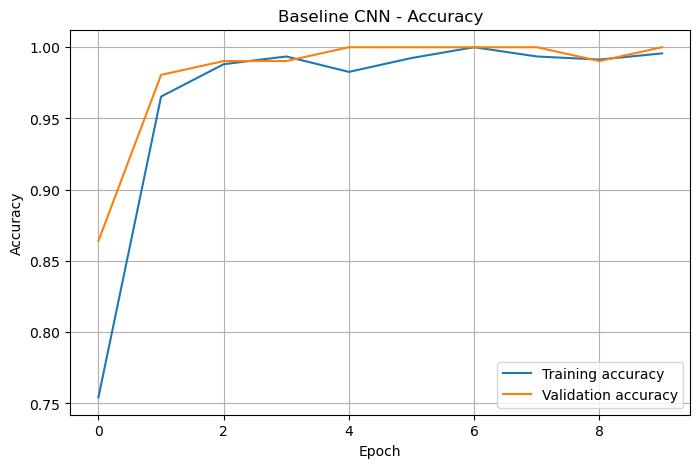

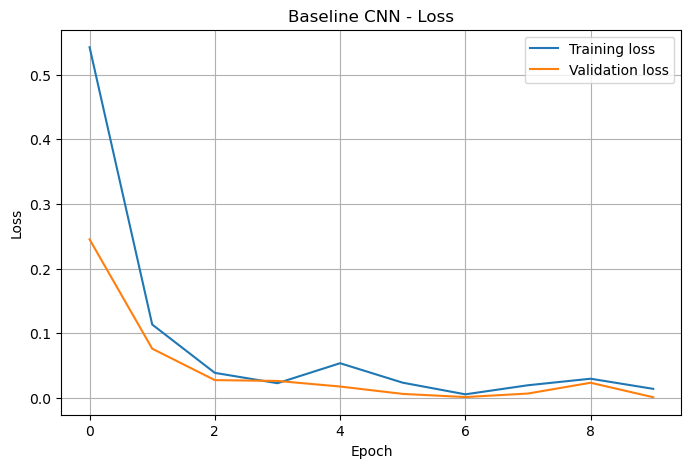

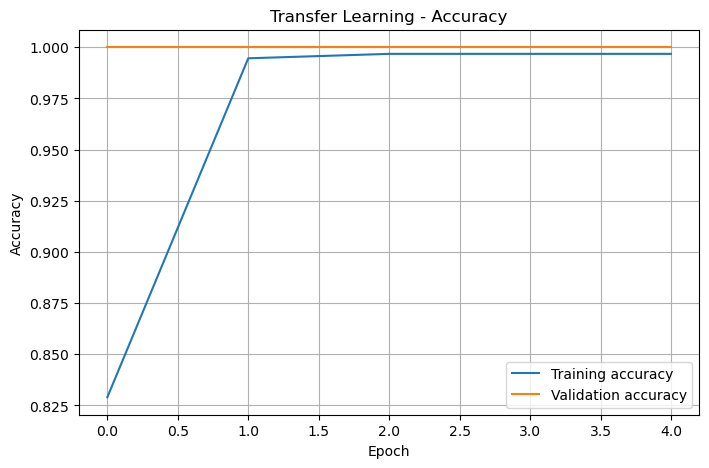

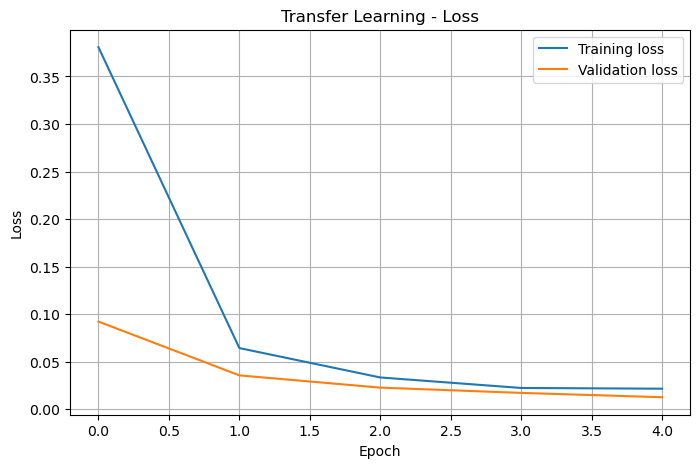

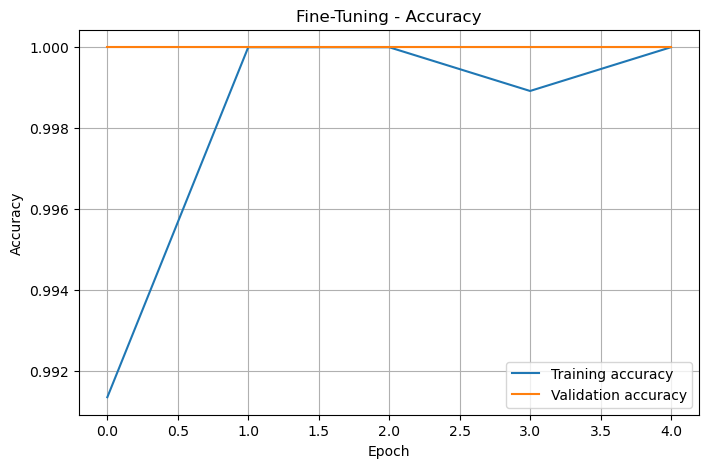

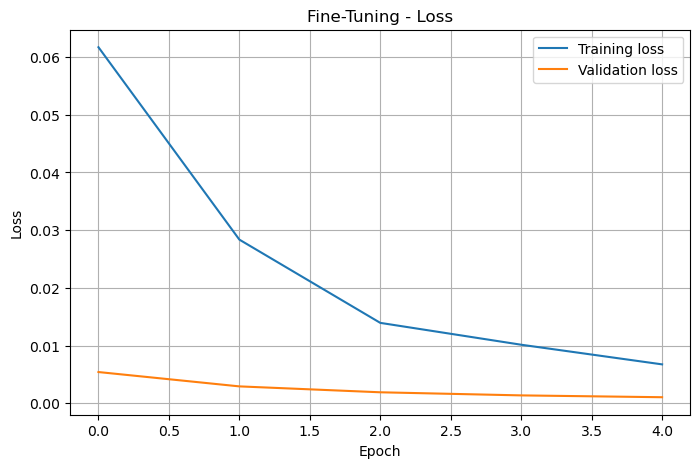

In [33]:
def plot_history(history, title):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["accuracy"], label="Training accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation accuracy")
    plt.title(title + " - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Training loss")
    plt.plot(history.history["val_loss"], label="Validation loss")
    plt.title(title + " - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_history(cnn_history, "Baseline CNN")
plot_history(transfer_history, "Transfer Learning")
plot_history(fine_tune_history, "Fine-Tuning")


## 15. Confusion Matrix and Classification Report


In [34]:
y_true = []
y_pred = []

for images, labels in test_transfer:
    predictions = transfer_model.predict(images, verbose=0)
    predicted_labels = (predictions > 0.5).astype(int).flatten()

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

cm = confusion_matrix(y_true, y_pred)

print("Confusion matrix:")
print(cm)

print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=class_names))


Confusion matrix:
[[127   1]
 [  0 128]]

Classification report:
              precision    recall  f1-score   support

       horse       1.00      0.99      1.00       128
       human       0.99      1.00      1.00       128

    accuracy                           1.00       256
   macro avg       1.00      1.00      1.00       256
weighted avg       1.00      1.00      1.00       256



## 16. Visualize Predictions


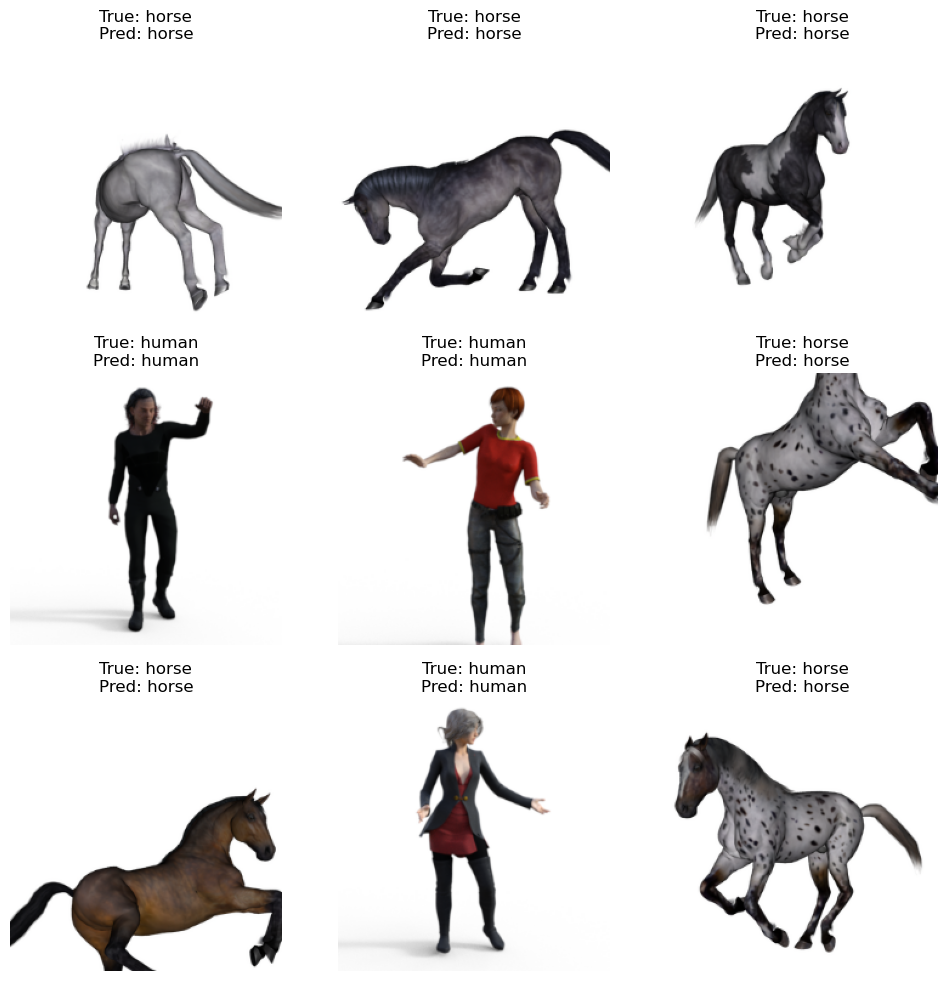

In [35]:
plt.figure(figsize=(12, 12))

for images, labels in test_transfer.take(1):
    predictions = transfer_model.predict(images, verbose=0)
    predicted_labels = (predictions > 0.5).astype(int).flatten()

    # Convert MobileNetV2-preprocessed images back to displayable format
    display_images = (images.numpy() + 1.0) / 2.0
    display_images = np.clip(display_images, 0, 1)

    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)
        plt.imshow(display_images[i])
        true_label = class_names[int(labels[i])]
        predicted_label = class_names[int(predicted_labels[i])]
        plt.title(f"True: {true_label}\nPred: {predicted_label}")
        plt.axis("off")

plt.show()
